# Network Anomaly Detection

## Random Forests
A Random Forest trains many decision trees on random subsets of your data, then combines their outputs — majority vote for classification, average for regression — so the crowd's wisdom beats any single tree, cutting overfitting while staying robust across complex, high-dimensional datasets.

A trained model learns what "normal" looks like, then flags anything that doesn't fit as a potential anomaly — handy for catching things like suspicious network traffic.

## Downloading the NSL-KDD Dataset
NSL-KDD is a cleaned-up benchmark dataset of labeled normal and attack network traffic, commonly used to train and test intrusion detection models — supporting both binary (normal vs. attack) and multi-class (attack type) classification. We'll be using a modified version of it.

In [ ]:
import requests, zipfile, io

# URL for the NSL-KDD dataset
url = "https://academy.hackthebox.com/storage/modules/292/KDD_dataset.zip"

# Download the zip file and extract its contents
response = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(response.content))
z.extractall('.')  # Extracts to the current directory

## Loading the Dataset
We begin by importing all necessary libraries.

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt # visualization: confusion matrix & feature importance plots

### Defining Column Names and File Path
Map column names to the NSL-KDD features and set the file path for pandas to load the dataset.

In [2]:
# Set the file path to the dataset
file_path = r'KDD+.txt'

# Define the column names corresponding to the NSL-KDD dataset
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 
    'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack', 'level'
]

### Reading the Dataset into a DataFrame
With the file path and column names defined, we load the data into a pandas DataFrame. This provides a structured, tabular representation of the dataset, making it easier to inspect, preprocess, and visualize.

The DataFrame is ready for further inspection, cleaning, and preprocessing steps. Before proceeding, we can briefly examine the dataset’s structure, check for missing values, and confirm that all features align with their intended data types.

In [ ]:
# Read the combined NSL-KDD dataset into a DataFrame
df = pd.read_csv(file_path, names=columns)

print(df.head())

# Preprocessing and Splitting the Dataset

## Preprocessing the Dataset
Prepare the NSL-KDD dataset for training by building two classification targets (binary: normal vs. attack, multi-class: attack type), encoding categorical variables into numeric form, and selecting the relevant numeric features — producing a clean, model-ready dataset.

### Creating a Binary Classification Target
Create a binary `attack_flag` column that labels each row as `0` (normal) or `1` (attack), reducing the problem to a simple normal-vs-attack classification before tackling more granular multi-class detection.

In [4]:
# Binary classification target
# Maps normal traffic to 0 and any type of attack to 1
df['attack_flag'] = df['attack'].apply(lambda a: 0 if a == 'normal' else 1)

### Creating the Multi-Class Classification Target
Extend binary labels into a 5-class target by mapping each attack name to its category — normal (0), DoS (1), Probe (2), Privilege Escalation (3), or Access (4) — giving the model enough granularity to identify not just *that* an attack occurred, but *what kind*.

In [5]:
# Multi-class classification target categories
dos_attacks = ['apache2', 'back', 'land', 'neptune', 'mailbomb', 'pod', 
               'processtable', 'smurf', 'teardrop', 'udpstorm', 'worm']
probe_attacks = ['ipsweep', 'mscan', 'nmap', 'portsweep', 'saint', 'satan']
privilege_attacks = ['buffer_overflow', 'loadmdoule', 'perl', 'ps', 
                     'rootkit', 'sqlattack', 'xterm']
access_attacks = ['ftp_write', 'guess_passwd', 'http_tunnel', 'imap', 
                  'multihop', 'named', 'phf', 'sendmail', 'snmpgetattack', 
                  'snmpguess', 'spy', 'warezclient', 'warezmaster', 
                  'xclock', 'xsnoop']

def map_attack(attack):
    if attack in dos_attacks:
        return 1
    elif attack in probe_attacks:
        return 2
    elif attack in privilege_attacks:
        return 3
    elif attack in access_attacks:
        return 4
    else:
        return 0

# Assign multi-class category to each row
df['attack_map'] = df['attack'].apply(map_attack)

### Encoding Categorical Variables
One-hot encode `protocol_type` and `service` into binary indicator columns using `pd.get_dummies`, converting categorical network attributes into numeric form without implying any ordinal relationship between categories.

If you encode `tcp=1, udp=2, icmp=3`, the model might learn "icmp is 3x tcp" or weight higher numbers more — total nonsense for protocols. One-hot gives you:

| tcp | udp | icmp |
|-----|-----|------|
| 1   | 0   | 0    |
| 0   | 1   | 0    |
| 0   | 0   | 1    |

Each protocol is just present or absent — no false relationships.

In [6]:
# Encoding categorical variables
features_to_encode = ['protocol_type', 'service']
encoded = pd.get_dummies(df[features_to_encode])

### Selecting Numeric Features
Select the numeric features — spanning raw traffic metrics like `src_bytes` and `dst_bytes` through derived statistical rates like `serror_rate` — that give the model both volume signals and behavioral patterns for distinguishing normal from attack traffic.

In [7]:
# Numeric features that capture various statistical properties of the traffic
numeric_features = [
    'duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'urgent', 'hot', 
    'num_failed_logins', 'num_compromised', 'root_shell', 'su_attempted', 
    'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 
    'num_outbound_cmds', 'count', 'srv_count', 'serror_rate', 
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 
    'dst_host_srv_rerror_rate'
]

### Preparing the Dataset
Concatenate the one-hot encoded categoricals with the numeric features into a single `train_set` DataFrame, and store the multi-class labels as `multi_y` — the dataset is now fully prepared for train/test splitting and model training.

Three types across the full pipeline:

- **numeric** — raw and derived traffic stats (int/float)
- **bool** — one-hot encoded protocol/service columns
- **int** — `attack_flag` (0/1) and `attack_map` (0-4) labels
- 
`multi_y` is the target/label, not a feature — you never train on what you're trying to predict. It stays separate so you can pass train_set (features) and multi_y (labels) independently into the model.

In [8]:
# Combine encoded categorical variables and numeric features
train_set = encoded.join(df[numeric_features])

# Multi-class target variable
multi_y = df['attack_map']

## Splitting the Dataset
Apply the train/validation/test split to the prepared NSL-KDD data, ensuring the random forest is trained, tuned, and evaluated on strictly separate subsets to give an honest measure of real-world performance.

### Splitting Data into Training and Test Sets
We use train_test_split to allocate a portion of the data for testing, ensuring that our final evaluations occur on unseen data.

In [9]:
# Split data into training and test sets for multi-class classification
train_X, test_X, train_y, test_y = train_test_split(train_set, multi_y, test_size=0.2, random_state=1337)

### Creating a Validation Set from the Training Data
We further split the training data to create a validation set. This supports model tuning and hyperparameter optimization without contaminating the final test data.

Four sets total after both splits:

- **`multi_train_X/y`** — trains the model
- **`multi_val_X/y`** — tunes hyperparameters during development
- **`test_X/y`** — final honest evaluation, touched only once at the end

`train_X/y` is now just an intermediate that got split further into train and val.

X is features (input), y is labels (target). Always pairs because every row in X needs its corresponding label in y to be meaningful.

In [10]:
# Further split the training set into separate training and validation sets
multi_train_X, multi_val_X, multi_train_y, multi_val_y = train_test_split(train_X, train_y, test_size=0.3, random_state=1337)

### Final Split Variables
After splitting, we have:

- train_X, train_y: Core training set
- test_X, test_y: Reserved for the final performance evaluation
- multi_train_X, multi_train_y: Training subset for fitting the model
- multi_val_X, multi_val_y: Validation subset for hyperparameter tuning

80% → train, 20% → test.
So of the full dataset:

- test: 20%
- multi_train: 80% × 70% = 56%
- multi_val: 80% × 30% = 24%

# Training and Evaluation (Network Anomaly Detection)
In this section, we will train a random forest model on the NSL-KDD dataset for multi-class classification. The goal is to build a model that can accurately classify network traffic into different attack categories or as normal traffic.

## Training the Model
Train a Random Forest model using the training data. Set `random_state=1337` for reproducibility, then fit the model on the training features and labels so it can learn patterns from the data.

In [11]:
# Train RandomForest model for multi-class classification
rf_model_multi = RandomForestClassifier(random_state=1337)
rf_model_multi.fit(multi_train_X, multi_train_y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Evaluating the Model on the Validation Set
Evaluate the trained model on the validation set to check how well it performs on data it hasn't seen before.

Validation Set Evaluation:
Accuracy: 0.9950
Precision: 0.9949
Recall: 0.9950
F1-Score: 0.9949


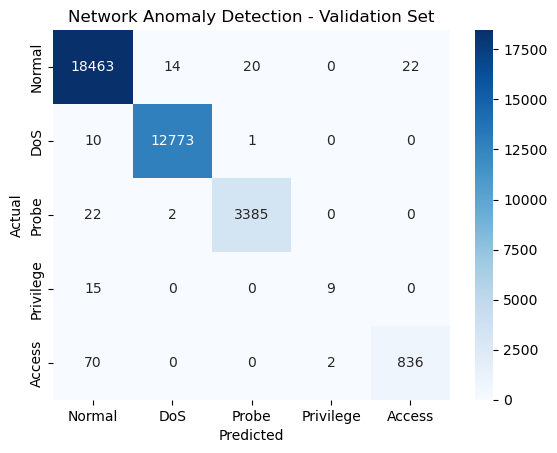

Classification Report for Validation Set:
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     18519
         DoS       1.00      1.00      1.00     12784
       Probe       0.99      0.99      0.99      3409
   Privilege       0.82      0.38      0.51        24
      Access       0.97      0.92      0.95       908

    accuracy                           1.00     35644
   macro avg       0.96      0.86      0.89     35644
weighted avg       0.99      1.00      0.99     35644



In [12]:
# Predict and evaluate the model on the validation set
multi_predictions = rf_model_multi.predict(multi_val_X)
accuracy = accuracy_score(multi_val_y, multi_predictions)
precision = precision_score(multi_val_y, multi_predictions, average='weighted')
recall = recall_score(multi_val_y, multi_predictions, average='weighted')
# f1 score: the harmonic mean of precision and recall, balances catching true positives against avoiding false positives
f1 = f1_score(multi_val_y, multi_predictions, average='weighted')
print(f"Validation Set Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Confusion Matrix for Validation Set
conf_matrix = confusion_matrix(multi_val_y, multi_predictions)
class_labels = ['Normal', 'DoS', 'Probe', 'Privilege', 'Access']
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Network Anomaly Detection - Validation Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report for Validation Set
print("Classification Report for Validation Set:")
print(classification_report(multi_val_y, multi_predictions, target_names=class_labels))

## Testing the Model on the Test Set
Evaluate the model on the test set for a final measure of how well it generalizes to completely unseen data.


Test Set Evaluation:
Accuracy: 0.9949
Precision: 0.9947
Recall: 0.9949
F1-Score: 0.9947


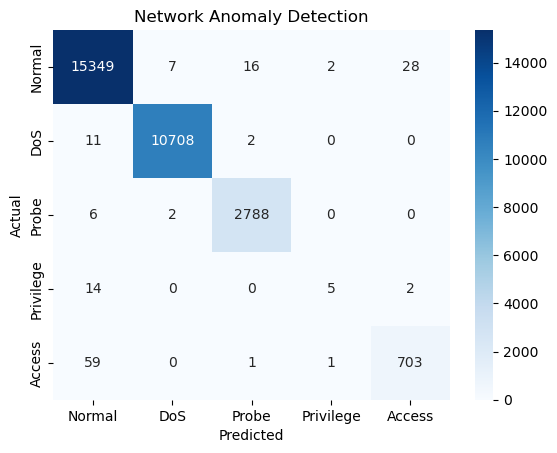

Classification Report for Test Set:
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     15402
         DoS       1.00      1.00      1.00     10721
       Probe       0.99      1.00      1.00      2796
   Privilege       0.62      0.24      0.34        21
      Access       0.96      0.92      0.94       764

    accuracy                           0.99     29704
   macro avg       0.91      0.83      0.85     29704
weighted avg       0.99      0.99      0.99     29704



In [13]:
# Final evaluation on the test set
test_multi_predictions = rf_model_multi.predict(test_X)
test_accuracy = accuracy_score(test_y, test_multi_predictions)
test_precision = precision_score(test_y, test_multi_predictions, average='weighted')
test_recall = recall_score(test_y, test_multi_predictions, average='weighted')
test_f1 = f1_score(test_y, test_multi_predictions, average='weighted')
print("\nTest Set Evaluation:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")

# Confusion Matrix for Test Set
test_conf_matrix = confusion_matrix(test_y, test_multi_predictions)
sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Network Anomaly Detection')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report for Test Set
print("Classification Report for Test Set:")
print(classification_report(test_y, test_multi_predictions, target_names=class_labels))

**Train → Validate → Test**

Fit the model on multi_train
Tune hyperparameters using multi_val (adjust until metrics look good)
Final eval on test — touch this only once, at the end

multi_train + multi_val are both carved out of the original train split, so test stays completely untouched until you're done experimenting.

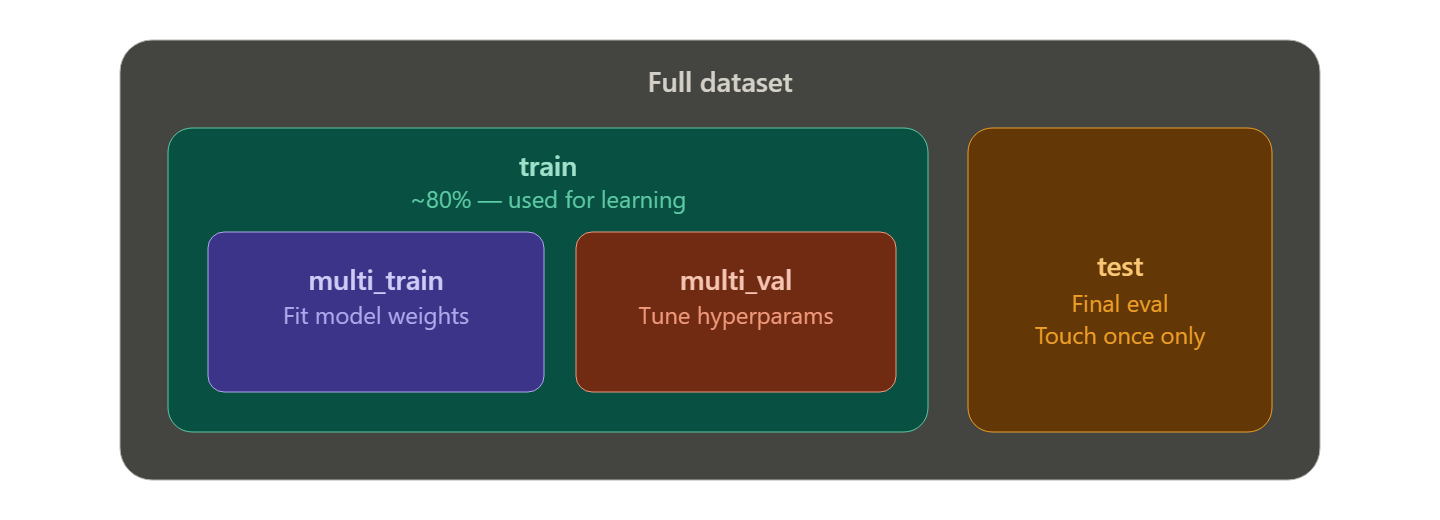

## Saving the Model

In [14]:
import joblib

# Save the trained model to a file
model_filename = 'network_anomaly_detection_model.joblib'
joblib.dump(rf_model_multi, model_filename)

print(f"Model saved to {model_filename}")

Model saved to network_anomaly_detection_model.joblib
